<a href="https://colab.research.google.com/github/opherdonchin/BayesShortCourse/blob/main/sleep/01_linear_baseline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Sleep deprivation 1 — Linear baseline

Start with one population-average linear relationship. Because `Days = 0` is the pre-deprivation baseline, the intercept has a direct scientific interpretation and we put its prior on that scale.

## Setup

This course pins PyMC, modular ArviZ, and Bambi for reproducibility because their APIs can change across major versions.

In [1]:
%pip install -q \
    "pymc==6.3.2" \
    "arviz-base==1.3.0" \
    "arviz-stats==1.3.2" \
    "arviz-plots[matplotlib]==1.3.1" \
    "bambi==0.21.0" \
    "jinja2>=3.1.5"

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: C:\Users\admin_local\dev\learning\BayesianShortCourse\.venv\Scripts\python.exe -m pip install --upgrade pip


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import bambi as bmb
import pymc as pm
import arviz_base as azb
import arviz_stats as azs
import arviz_plots as azp

RANDOM_SEED = 20260924
azp.style.use("arviz-variat")

print("PyMC:", pm.__version__)
print("Bambi:", bmb.__version__)
print("arviz-base:", azb.__version__)
print("arviz-plots:", azp.__version__)
print("arviz-stats:", azs.__version__)

g++ not available, if using conda: `conda install gxx`


PyMC: 6.3.2
Bambi: 0.21.0
arviz-base: 1.3.0
arviz-plots: 1.3.1
arviz-stats: 1.3.2


## Data

The original study contains two adaptation/training days followed by a baseline measurement and then seven nights of severe sleep restriction. Following the chapter, we drop original days 0–1 and subtract 2 from the remaining day number. Therefore **`Days = 0` is the baseline measurement before sleep deprivation begins**.

That zero point is scientifically meaningful, so every Bambi model in this sequence uses `center_predictors=False`. The `Intercept` prior is therefore a prior on baseline reaction time rather than reaction time at the average deprivation day.

In [3]:
DATA_URL = "https://raw.githubusercontent.com/vincentarelbundock/Rdatasets/master/csv/lme4/sleepstudy.csv"

sleep = pd.read_csv(DATA_URL).drop(columns="rownames")
sleep = sleep.loc[sleep["Days"] >= 2].copy()
sleep["Days"] = sleep["Days"] - 2
sleep["Subject"] = sleep["Subject"].astype(str)
sleep = sleep.reset_index(drop=True)

print(f"{sleep['Subject'].nunique()} participants, {len(sleep)} observations")
print(f"Days: {sleep['Days'].min()} to {sleep['Days'].max()}")
sleep.head()

18 participants, 144 observations
Days: 0 to 7


,Reaction,Days,Subject
0,250.8006,0,308
1,321.4398,1,308
2,356.8519,2,308
3,414.6901,3,308
4,382.2038,4,308


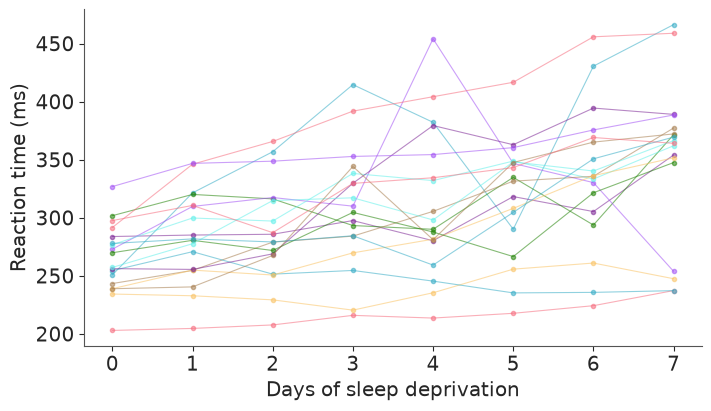

In [4]:
fig, ax = plt.subplots(figsize=(7, 4))
for subject, group in sleep.groupby("Subject"):
    ax.plot(group["Days"], group["Reaction"], marker="o", ms=3, lw=0.8, alpha=0.55)
ax.set(xlabel="Days of sleep deprivation", ylabel="Reaction time (ms)")
plt.show()

# 1.1 Prior implications

What reaction times and daily sleep-deprivation effects are plausible before seeing the data?

The model is

$$\text{Reaction}_i \sim \mathcal{N}(\alpha + \beta \cdot \text{Days}_i,\ \sigma)$$

We set the priors from the literature, not from this dataset:

- **Intercept $\alpha$ (baseline RT, `Days = 0`) $\sim \mathcal{N}(250, 30)$ ms.** Well-rested adults average about 250 ms on the psychomotor vigilance test (PVT), and most fall between 200 and 300 ms ([Basner & Dinges 2011](https://pubmed.ncbi.nlm.nih.gov/21532951/); [Basner et al. 2020](https://pmc.ncbi.nlm.nih.gov/articles/PMC8240655/)).
- **Slope $\beta$ (change per day of restriction) $\sim \mathcal{N}(10, 10)$ ms/day.** Belenky et al. (2003), the source of this dataset, found that PVT speed declined steadily over 7 nights of 3 h time in bed ([Belenky et al. 2003](https://onlinelibrary.wiley.com/doi/abs/10.1046/j.1365-2869.2003.00337.x)). So we expect slowing, but we leave room for no effect ($\beta \approx 0$) and for large effects (~30 ms/day, i.e. +200 ms after a week).
- **Residual SD $\sigma \sim \text{HalfNormal}(50)$ ms.** This covers both between-person and day-to-day variation, which this model cannot yet tell apart.

### Check 1: prior predictive

Before touching the data, we simulate reaction times from the priors alone and ask whether they look like plausible human reaction times: no negative or implausibly fast values, and a plausible range of effects.

In [5]:
priors = {
    "Intercept": bmb.Prior("Normal", mu=250, sigma=30),
    "Days": bmb.Prior("Normal", mu=10, sigma=10),
    "sigma": bmb.Prior("HalfNormal", sigma=50),
}
model = bmb.Model("Reaction ~ Days", sleep, priors=priors, center_predictors=False)
model.build()

with model.backend.model:
    prior = pm.sample_prior_predictive(draws=500, random_seed=RANDOM_SEED)
model

Sampling: [Days, Intercept, Reaction, sigma]


       Formula: Reaction ~ Days
        Family: gaussian
          Link: mu = identity
  Observations: 144
        Priors: 
    target = mu
        Common-level effects
            Intercept ~ Normal(mu: 250.0, sigma: 30.0)
            Days ~ Normal(mu: 10.0, sigma: 10.0)
        
        Auxiliary parameters
            sigma ~ HalfNormal(sigma: 50.0)

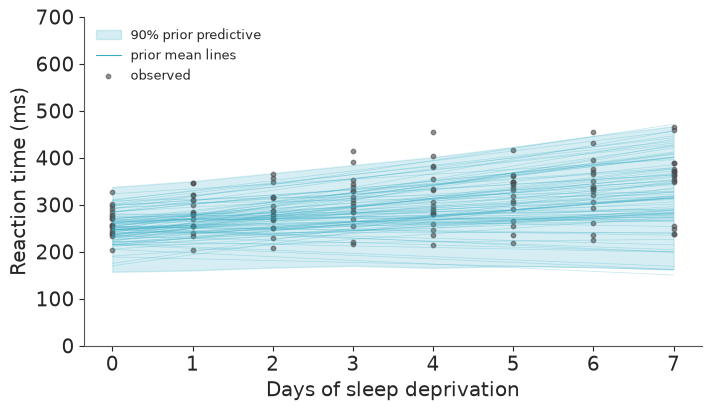

P(slope < 0)              = 0.15
P(mean RT at day 7 > 500) = 0.01
P(predicted RT < 100 ms)  = 0.012
P(predicted RT < 0 ms)    = 0.0016


In [6]:
alpha = prior["prior"]["Intercept"].values.ravel()
beta = prior["prior"]["Days"].values.ravel()
y_prior = prior["prior_predictive"]["Reaction"].values.reshape(-1, len(sleep))

days = np.arange(8)
fig, ax = plt.subplots(figsize=(7, 4))
# 90% prior predictive interval for a single observation on each day
band = np.array([np.percentile(y_prior[:, sleep["Days"] == d], [5, 95]) for d in days])
ax.fill_between(days, band[:, 0], band[:, 1], color="C0", alpha=0.2, label="90% prior predictive")
# 100 prior draws of the population-average line
for a, b in zip(alpha[:100], beta[:100]):
    ax.plot(days, a + b * days, color="C0", lw=0.5, alpha=0.3)
ax.plot([], [], color="C0", lw=0.8, label="prior mean lines")
ax.scatter(sleep["Days"], sleep["Reaction"], s=10, color="0.3", alpha=0.6, label="observed")
ax.set(xlabel="Days of sleep deprivation", ylabel="Reaction time (ms)", ylim=(0, 700))
ax.legend(frameon=False, fontsize=9, loc="upper left")
plt.show()

print(f"P(slope < 0)              = {(beta < 0).mean():.2f}")
print(f"P(mean RT at day 7 > 500) = {(alpha + 7 * beta > 500).mean():.2f}")
print(f"P(predicted RT < 100 ms)  = {(y_prior < 100).mean():.3f}")
print(f"P(predicted RT < 0 ms)    = {(y_prior < 0).mean():.4f}")

The same simulated data as a distribution: each blue line is one prior draw's 144 simulated reaction times, and the black line is the observed data. The posterior predictive check in 1.3 uses the same ECDF plot.

ArviZ hides the observed data in prior checks by default, because priors should come from domain knowledge, not be tuned to the data you are about to fit. We show the data here only as a sanity check: **could** these priors have produced data like ours? We don't change the priors based on the overlay.

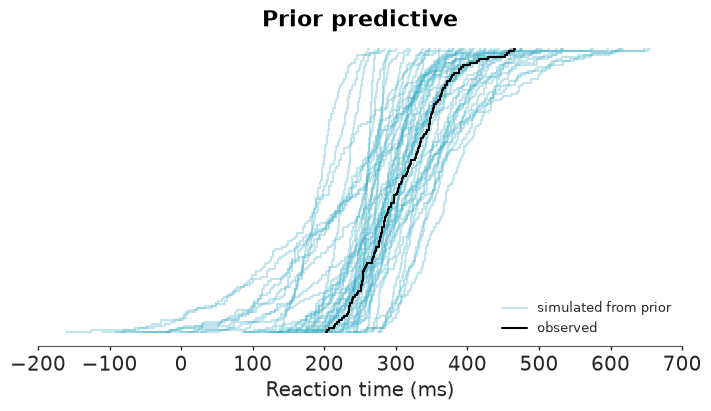

In [7]:
azp.plot_ppc_dist(prior, group="prior_predictive", var_names=["Reaction"], kind="ecdf",
                  visuals={"observed_dist": True}, figure_kwargs={"figsize": (7, 4)})

ax = plt.gcf().axes[0]
ax.set(xlabel="Reaction time (ms)", title="Prior predictive", xlim=(-200, 700))
ax.legend([ax.lines[0], ax.lines[-1]], ["simulated from prior", "observed"], frameon=False, fontsize=9, loc="lower right")
plt.show()

**Verdict: the priors pass.** They generate plausible reaction times: 90% of simulated values fall between about 155 and 470 ms. The average lines range from slightly faster to much slower over the week, and 15% of draws have a negative slope, so "no effect" is not ruled out. The observed data fall inside the prior predictive band, and their ECDF runs through the middle of the simulated ones: the priors could have produced data like ours without already dictating the answer.

One flaw: a few simulated values are impossible. 1.2% are below 100 ms and 0.16% below 0 ms. That comes from the Gaussian likelihood, which has no lower bound, and we meet it again in 1.3.

# 1.2 Population effect

What population-average change in reaction time does the data support?

We fit the model and check the sampler before reading any numbers. Then we summarize three population-level quantities:

- **Baseline mean** $\alpha$: average RT before deprivation (`Days = 0`).
- **Daily increase** $\beta$: average extra ms of RT per day of restriction.
- **Total increase** $7\beta$: average extra ms after all 7 days (day 7 vs. day 0).

These describe uncertainty about the *average* line. They are not predictions for an individual person (that is 1.3).

### Check 2: sampler diagnostics

Before interpreting any estimate, we check that MCMC explored the posterior properly:

- **Divergences** should be 0.
- **$\hat R \le 1.01$**: the 4 chains agree with each other.
- **ESS** (effective sample size) in the hundreds or more, for both the bulk and the tails.
- **Rank plots:** each chain's rank distribution should be flat and stay inside the envelope. A chain that is stuck or drifting shows up as a bump or dip.

In [8]:
idata = model.fit(draws=2000, tune=2000, chains=4, random_seed=RANDOM_SEED)

print("Divergences:", int(idata["sample_stats"]["diverging"].sum()))
azs.summary(idata, var_names=["Intercept", "Days", "sigma"], ci_prob=0.9, ci_kind="hdi")

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [sigma, Intercept, Days]


Output()

Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 19 seconds.


Divergences: 0


,mean,sd,hdi90_lb,hdi90_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
Intercept,267,7.5,250,280,4426,4637,1.00,0.11,0.084
Days,11.61,1.8,8.6,14,4347,4657,1.00,0.027,0.02
sigma,51.1,2.99,46,56,5063,4536,1.00,0.042,0.037


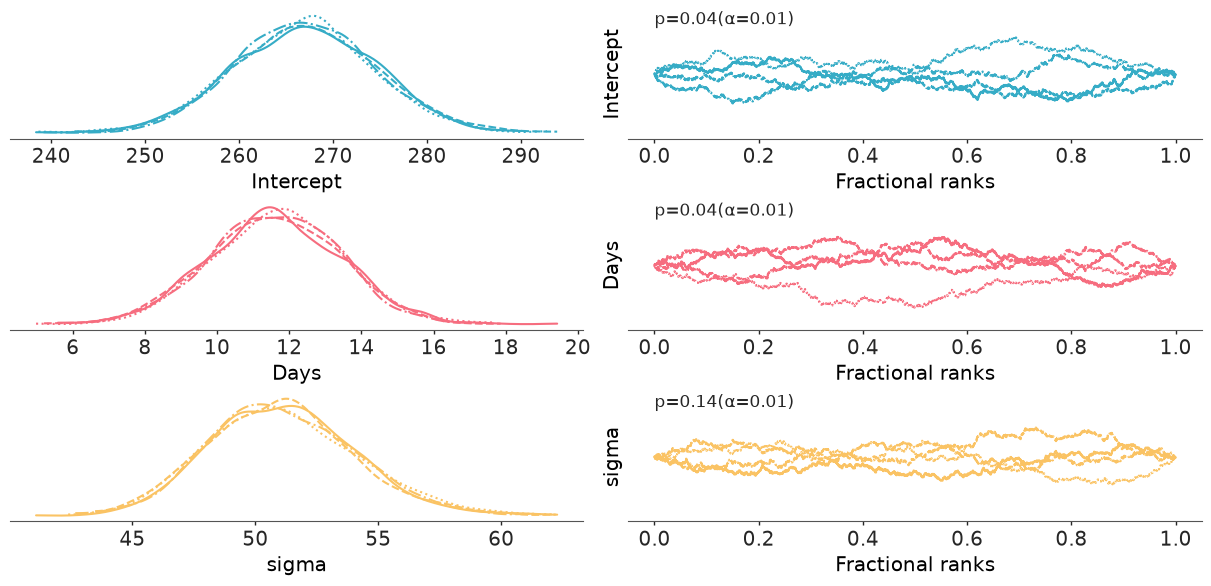

In [9]:
azp.plot_rank_dist(idata, var_names=["Intercept", "Days", "sigma"]);

**Verdict: the sampler passes.** There are 0 divergences, $\hat R = 1.00$ and bulk and tail ESS above 4300 for every parameter. The rank tests pass for all three parameters (p = 0.04, 0.04, 0.14, all above α = 0.01), and the chains' distributions overlap.

The rank plot earned its place. With the default 1000 warm-up + 1000 draws, $\hat R$ and ESS also looked perfect, yet the rank test **failed** for `Days` (p = 0.00) because one chain sat systematically low. Because `Days` is not centred, the intercept and slope are strongly correlated in the posterior, so the chains mix slowly. Running longer (2000 + 2000) fixed it. The summary numbers alone would have missed it.

In [10]:
post = idata["posterior"]
post["baseline_mean"] = post["Intercept"]
post["daily_increase"] = post["Days"]
post["total_increase_7d"] = 7 * post["Days"]
post["day7_mean"] = post["Intercept"] + 7 * post["Days"]

azs.summary(
    idata,
    var_names=["baseline_mean", "daily_increase", "total_increase_7d", "day7_mean"],
    kind="stats",
    ci_prob=0.9,
    ci_kind="hdi",
    round_to=1,
)

,mean,sd,hdi90_lb,hdi90_ub
baseline_mean,267.0,7.5,254.9,279.4
daily_increase,11.6,1.8,8.6,14.4
total_increase_7d,81.3,12.6,59.9,100.8
day7_mean,348.3,7.7,335.8,361.0


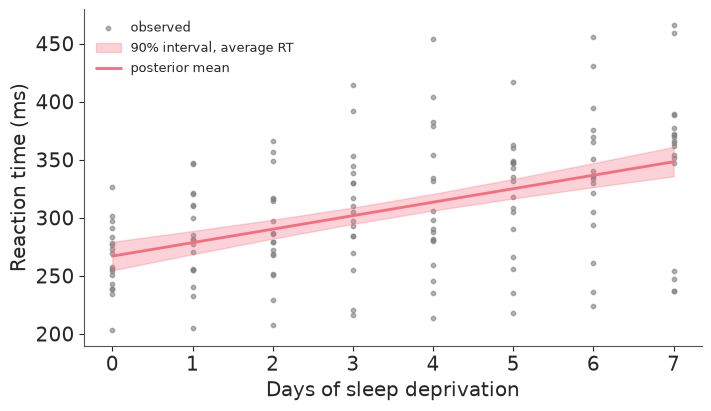

In [11]:
alpha_post = post["Intercept"].values.ravel()
beta_post = post["Days"].values.ravel()
mu = alpha_post[:, None] + beta_post[:, None] * days  # posterior of the average line

fig, ax = plt.subplots(figsize=(7, 4))
ax.scatter(sleep["Days"], sleep["Reaction"], s=10, color="0.5", alpha=0.6, label="observed")
ax.fill_between(days, *np.percentile(mu, [5, 95], axis=0), color="C1", alpha=0.3, label="90% interval, average RT")
ax.plot(days, mu.mean(axis=0), color="C1", lw=2, label="posterior mean")
ax.set(xlabel="Days of sleep deprivation", ylabel="Reaction time (ms)")
ax.legend(frameon=False, fontsize=9, loc="upper left")
plt.show()

**Answer.** Before deprivation the average RT is about **267 ms** (90% HDI 255–279), a little slower than the ~250 ms literature value. RT rises by about **11.6 ms per day** (8.6–14.4), so over the 7 days the average RT increases by about **81 ms** (60–101), to roughly **348 ms** on day 7.

**Reading the answer** (from the summary table above, posterior mean and 90% HDI):

- *What is the mean?* `baseline_mean` is the average rested RT. Compare it with the ~250 ms from the literature.
- *Mean increase per day?* `daily_increase`. If its 90% HDI is well above 0, the data support steady slowing.
- *Total increase over all days?* `total_increase_7d` is the average slowing from day 0 to day 7, and `day7_mean` is the average RT at day 7.

The band in the plot is uncertainty about the **average** line. It is narrow even though individual participants scatter widely around it. That spread is what 1.3 and 1.5 look at.

# 1.3 Predictive adequacy

Can a single population-average line reproduce the observed reaction-time distribution?

### Check 3: posterior predictive

We now simulate **new observations** from the fitted model (posterior predictive), not just the average line. The first plot uses the same layout as the prior check in 1.1, so you can see what conditioning on the data changed.

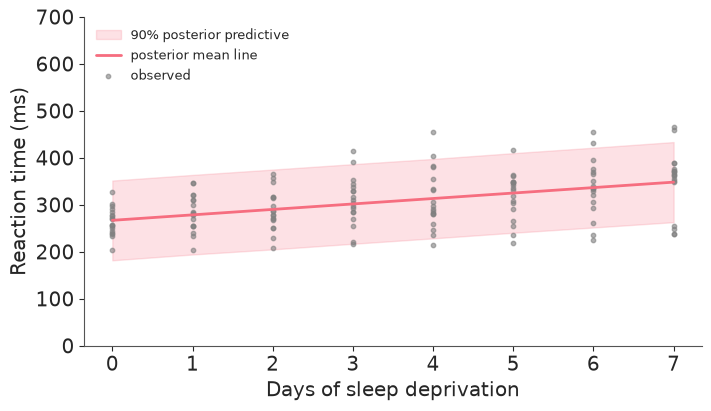

Days
0    1.00
1    1.00
2    1.00
3    0.83
4    0.83
5    0.83
6    0.78
7    0.67


In [12]:
model.predict(idata, kind="response", inplace=True, random_seed=RANDOM_SEED)
y_post = idata["posterior_predictive"]["Reaction"].values.reshape(-1, len(sleep))

fig, ax = plt.subplots(figsize=(7, 4))
band = np.array([np.percentile(y_post[:, sleep["Days"] == d], [5, 95]) for d in days])
ax.fill_between(days, band[:, 0], band[:, 1], color="C1", alpha=0.2, label="90% posterior predictive")
ax.plot(days, mu.mean(axis=0), color="C1", lw=2, label="posterior mean line")
ax.scatter(sleep["Days"], sleep["Reaction"], s=10, color="0.5", alpha=0.6, label="observed")
ax.set(xlabel="Days of sleep deprivation", ylabel="Reaction time (ms)", ylim=(0, 700))
ax.legend(frameon=False, fontsize=9, loc="upper left")
plt.show()

inside = (sleep["Reaction"] >= band[sleep["Days"], 0]) & (sleep["Reaction"] <= band[sleep["Days"], 1])
print(sleep.assign(inside_90=inside).groupby("Days")["inside_90"].mean().round(2).to_string())

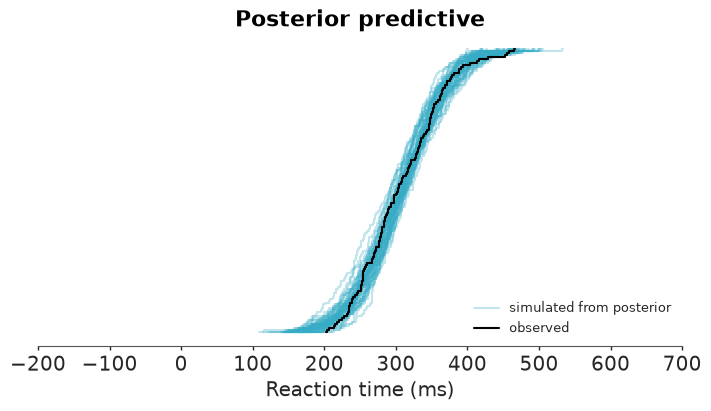

In [13]:
azp.plot_ppc_dist(idata, var_names=["Reaction"], kind="ecdf", figure_kwargs={"figsize": (7, 4)})

ax = plt.gcf().axes[0]
ax.set(xlabel="Reaction time (ms)", title="Posterior predictive", xlim=(-200, 700))
ax.legend([ax.lines[0], ax.lines[-1]], ["simulated from posterior", "observed"], frameon=False, fontsize=9, loc="lower right")
plt.show()

**Answer: only partly.** The population line tracks the average well, but two things don't fit:

- **The spread changes with deprivation.** On days 0–2 **every** observation falls inside the 90% predictive band, which is wider than needed. By day 7 only about **two thirds** do, so the band is too narrow. People diverge as deprivation goes on, and one constant $\sigma$ has to average over that.
- **The shape is wrong in the lower tail.** In the ECDF the model simulates reaction times down to about 110 ms, but the fastest observed RT is about 205 ms. A Gaussian is symmetric, while real RTs have a hard lower limit and a longer slow tail. Notebooks 06–09 replace the Gaussian with lognormal and ex-Gaussian likelihoods for this reason.

# 1.4 Prior sensitivity

How sensitive are the main posterior conclusions to modest changes in the priors?

**Power-scaling** answers this without refitting. It raises the prior (or the likelihood) to a power slightly above or below 1 and measures how far each posterior moves. Values above about 0.05 are flagged. A parameter that is sensitive to the prior but not the likelihood suggests the prior is dominating that result, and the data say little about it.

In [14]:
model.compute_log_likelihood(idata)  # Bambi adds these to idata in place
model.compute_log_prior(idata)

azs.psense_summary(idata, var_names=["Intercept", "Days", "sigma"])

,prior,likelihood,diagnosis
Intercept,0.022,0.087,✓
Days,0.016,0.084,✓
sigma,0.011,0.104,✓


As a stress test we also refit with two deliberately **extreme** intercept priors, keeping everything else the same: a nearly flat one, and a confident but wrong one centred at 300 ms.

In [15]:
alt_intercept_priors = {
    "Vague intercept N(250, 500)": bmb.Prior("Normal", mu=250, sigma=500),
    "Confident intercept N(300, 10)": bmb.Prior("Normal", mu=300, sigma=10),
}

fits = {"Literature prior N(250, 30)": idata}
for label, intercept_prior in alt_intercept_priors.items():
    alt_model = bmb.Model(
        "Reaction ~ Days", sleep, priors={**priors, "Intercept": intercept_prior}, center_predictors=False
    )
    fits[label] = alt_model.fit(draws=1000, chains=4, random_seed=RANDOM_SEED, progressbar=False)
    diag = azs.summary(fits[label], var_names=["Intercept", "Days", "sigma"], kind="diagnostics")
    print(f"{label}: divergences = {int(fits[label]['sample_stats']['diverging'].sum())}, "
          f"max R-hat = {diag['r_hat'].max():.3f}, min bulk ESS = {diag['ess_bulk'].min():.0f}")

pd.concat(
    {label: azs.summary(fit, var_names=["Intercept", "Days"], kind="stats", ci_prob=0.9, ci_kind="hdi", round_to=1)
     for label, fit in fits.items()}
)

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [sigma, Intercept, Days]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 20 seconds.


Initializing NUTS using jitter+adapt_diag...


...

Multiprocess sampling (4 chains in 4 jobs)


NUTS: [sigma, Intercept, Days]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 16 seconds.


Confident intercept N(300, 10): divergences = 0, max R-hat = 1.003, min bulk ESS = 2047


mean   sd  hdi90_lb  hdi90_ub
Literature prior N(250, 30)    Intercept  267.0  7.5     254.9     279.4
                               Days        11.6  1.8       8.6      14.4
Vague intercept N(250, 500)    Intercept  267.9  7.8     255.1     280.6
                               Days        11.4  1.8       8.5      14.5
Confident intercept N(300, 10) Intercept  280.2  6.3     270.0     290.6
                               Days         9.0  1.6       6.3      11.7

C:\Users\admin_local\dev\learning\BayesianShortCourse\.venv\Lib\site-packages\arviz_plots\plot_collection.py:58: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'draw' ('draw',) The recommendation is to set join explicitly for this case.
  data = xr.concat(ds_list, dim="model").assign_coords(model=list(data))


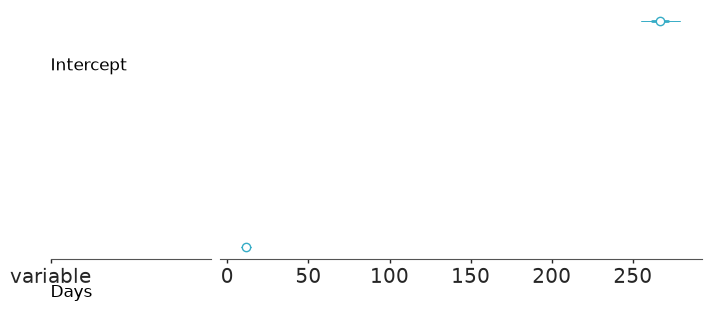

In [16]:
azp.plot_forest(fits, var_names=["Intercept", "Days"], combined=True, figure_kwargs={"figsize": (7, 3)});

**Answer: the conclusions are robust to modest prior changes.**

- Power-scaling flags nothing. Prior sensitivity is about 0.02 for every parameter, well under the 0.05 threshold, while likelihood sensitivity is higher. The 144 observations dominate.
- A nearly flat intercept prior gives essentially the same posterior (267.9 vs 267.1 ms, 11.4 vs 11.6 ms/day).
- Only the deliberately **wrong and confident** prior N(300, 10) moves things. It drags the baseline up to about 280 ms, and it also pulls the **slope** down to about 9 ms/day. The data pin down day-7 RT, so a higher starting point forces a flatter line. A prior on one parameter can change conclusions about another when the two are correlated in the posterior.

# 1.5 Missing structure

What important structure in the data does this population-average model fail to represent?

The model treats all 144 measurements as independent draws around one line. But they are **8 repeated measurements of each of 18 people**. If the model captured everything, each person's residuals (observed minus the population line) would scatter around 0.

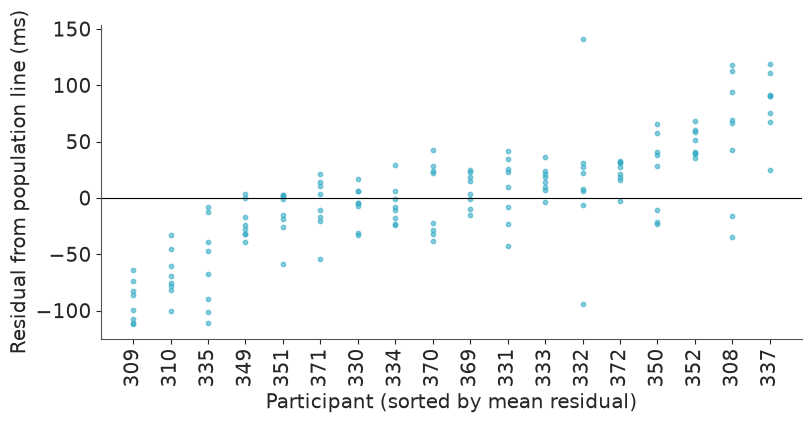

In [17]:
line = post["Intercept"].mean().item() + post["Days"].mean().item() * sleep["Days"]
sleep["resid"] = sleep["Reaction"] - line
order = sleep.groupby("Subject")["resid"].mean().sort_values().index

fig, ax = plt.subplots(figsize=(8, 4))
for i, subject in enumerate(order):
    r = sleep.loc[sleep["Subject"] == subject, "resid"]
    ax.scatter(np.full(len(r), i), r, s=10, color="C0", alpha=0.6)
ax.axhline(0, color="k", lw=0.8)
ax.set(xticks=range(len(order)), xlabel="Participant (sorted by mean residual)",
       ylabel="Residual from population line (ms)")
ax.set_xticklabels(order, rotation=90)
plt.show()

In [18]:
# Each participant's own least-squares line, versus the single population line
per_subject = sleep.groupby("Subject").apply(
    lambda g: pd.Series(np.polyfit(g["Days"], g["Reaction"], 1)[::-1], index=["baseline", "slope"]),
    include_groups=False,
)
per_subject.describe().loc[["mean", "std", "min", "max"]].round(1)

,baseline,slope
mean,268.0,11.4
std,35.1,7.8
min,200.3,-4.2
max,331.3,23.3


**Answer: the model has no participants in it.** The 144 rows are 18 people measured 8 times each:

- **People differ at baseline.** Residuals cluster by person: 8 of the 18 participants have at least 7 of their 8 residuals on the same side of zero (5 have all 8). Independent noise would rarely do that. Fitting each person's own line, baselines range from about **200 to 331 ms** (SD ≈ 35 ms).
- **People differ in how much they slow down.** Individual slopes range from about **−4 to +23 ms/day** (SD ≈ 8). One participant even got slightly faster. This is also why the spread widens over days in 1.3.
- **The observations are not independent.** Measurements from the same person are correlated, so the model has less independent information than 144 separate observations would give. The 90% intervals in 1.2 are therefore probably too narrow.

Notebooks 04 (varying intercept) and 05 (varying intercept and slope) add this participant-level structure.